## Plot Total Organic Column

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from pathlib import Path
import dill
import re
import matplotlib.dates as mdates
import matplotlib.lines as mlines

In [2]:
data = {}

for d in Path("../ModelOutputs/OrganicSoil/UpperOrganic").glob("VWC_*.dill"):
    with open(d, "rb") as f:
        out = dill.load(f)

    data[d.stem] = out   

In [3]:
first_key = list(data.keys())[0]
out = data[first_key]

In [4]:
T_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.T,
            columns=out.z,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        T_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [5]:
J_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.jT,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        J_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [6]:
def fake_date(df):
    dfe = df.iloc[74:].reset_index(drop = True)
    n = len(dfe)
    dates = pd.date_range("2000-01-01", periods=n, freq="D")
    dfe.index = dates
    return dfe

In [7]:
# apply fake date to all dataframes and changes them in dictionary
T_dfse = {}
T_dfse = {key: fake_date(df) for key, df in T_dfs.items()}

In [8]:
# apply fake date to all dataframes and changes them in dictionary
J_dfse = {}
J_dfse = {key: fake_date(df) for key, df in J_dfs.items()}

In [9]:
# Create mesh
nz=1250
dz=np.zeros(nz)+0.01
dz[:500] = 0.01 # 0 -5
dz[500:] = 0.02 # 5m - 20m
bz=np.hstack([0, np.cumsum(dz)])
z=(bz[:-1]+bz[1:])/2
zMax=bz[-1]

In [10]:
def depths(df,z):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

In [11]:
# apply depths to all the dataframes
T_dfs = {key: depths(df,z) for key, df in T_dfs.items()}
T_dfse = {key: depths(df,z) for key, df in T_dfse.items()}

In [12]:
def depths(df):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

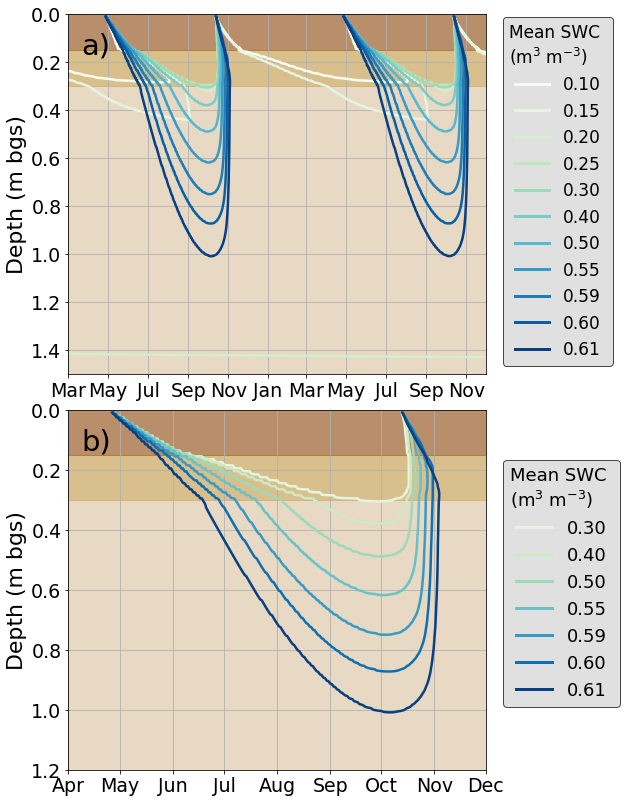

In [14]:
# ============================================================
# DATASETS
# ============================================================

datasets = (
    T_dfse['df_10'],
    T_dfse['df_15'],
    T_dfse['df_20'],
    T_dfse['df_25'],
    T_dfse['df_30'],
    T_dfse['df_40'],
    T_dfse['df_50'],
    T_dfse['df_60'],
    T_dfse['df_70'],
    T_dfse['df_80'],
    T_dfse['df_93'])

labels = ('0.10','0.15','0.20','0.25','0.30','0.40','0.50','0.55','0.59','0.60','0.61')

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    2, 1,
    figsize=(9, 12))

# ============================================================
# PANEL A
# ============================================================

# Background
ax[0].axhspan(0.0, 5, color='tan', alpha=0.5)

# Organic layers
ax[0].axhspan(
    0.0, 0.15,
    color='saddlebrown',
    alpha=0.5)

ax[0].axhspan(
    0.15, 0.30,
    color='darkgoldenrod',
    alpha=0.3)

# Colors
blues = plt.cm.GnBu(
    np.linspace(0, 1, len(datasets)))

# ------------------------------------------------------------
# 0 °C contours
# ------------------------------------------------------------

for data, vwc, color in zip(datasets, labels, blues):

    # For wetter simulations, don't search for the 0°C contour
    # below 2 
    if float(vwc) >= 0.15:
        data_plot = data.loc[
            :,
            data.columns.astype(float) <= 2.0]
    else:
        data_plot = data

    Time, Depth = np.meshgrid(
        data_plot.index,
        data_plot.columns.astype(float),
        indexing='ij')

    ax[0].contour(
        Time,
        Depth,
        data_plot.values,
        levels=[0],
        colors=[color],
        linewidths=2.5)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_lines = [
    mlines.Line2D(
        [],
        [],
        color=color,
        lw=3,
        label=label
    )
    for color, label in zip(blues, labels)]

leg = ax[0].legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.0),
    fontsize=17,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 17}
)

leg.get_frame().set_facecolor('lightgrey')
leg.get_frame().set_alpha(0.7)
leg.get_frame().set_edgecolor('black')

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax[0].invert_yaxis()

ax[0].set_ylim(1.5,0)

ax[0].set_ylabel(
    "Depth (m bgs)",
    fontsize=22)

ax[0].tick_params(
    axis='both',
    labelsize=19)

ax[0].grid()

start_date = pd.to_datetime('2001-03-01')
end_date = pd.to_datetime('2002-12-01')

ax[0].set_xlim(
    start_date,
    end_date)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%b'))

ax[0].text(
    0.03,
    0.95,
    "a)",
    transform=ax[0].transAxes,
    fontsize=29,
    va='top')

# ============================================================
# PANEL B
# ============================================================

datasets2 = ( T_dfse['df_30'],  T_dfse['df_40'],  T_dfse['df_50'], T_dfse['df_60'], T_dfse['df_70'], T_dfse['df_80'],  T_dfse['df_93'])

labels2 = ('0.30', '0.40','0.50','0.55','0.59','0.60','0.61')

# Background
ax[1].axhspan(
    0.0,
    5,
    color='tan',
    alpha=0.5
)

# Organic layers
ax[1].axhspan(
    0.0,
    0.15,
    color='saddlebrown',
    alpha=0.5)

ax[1].axhspan(
    0.15,
    0.30,
    color='darkgoldenrod',
    alpha=0.3)

# Colors
blues2 = plt.cm.GnBu(
    np.linspace(0.1, 1, len(datasets2)))

# ------------------------------------------------------------
# 0 °C contours
# ------------------------------------------------------------

for data, vwc, color in zip(
    datasets2,
    labels2,
    blues2):

    # Same depth restriction
    if float(vwc) >= 0.15:
        data_plot = data.loc[
            :,
            data.columns.astype(float) <= 2.0
        ]
    else:
        data_plot = data

    Time, Depth = np.meshgrid(
        data_plot.index,
        data_plot.columns.astype(float),
        indexing='ij'    )

    ax[1].contour(
        Time,
        Depth,
        data_plot.values,
        levels=[0],
        colors=[color],
        linewidths=2.5  )

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_lines2 = [
    mlines.Line2D(
        [],
        [],
        color=color,
        lw=3,
        label=label
    )
    for color, label in zip(blues2, labels2)]

leg2 = ax[1].legend(
    handles=legend_lines2,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.15),
    fontsize=18,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 18})

leg2.get_frame().set_facecolor('lightgrey')
leg2.get_frame().set_alpha(0.7)
leg2.get_frame().set_edgecolor('black')

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax[1].invert_yaxis()

ax[1].set_ylim(
    1.2,
    0)

ax[1].set_ylabel(
    "Depth (m bgs)",
    fontsize=22)

ax[1].tick_params(
    axis='both',
    labelsize=19)

ax[1].grid()

start_date2 = pd.to_datetime('2002-04-01')
end_date2 = pd.to_datetime('2002-12-01')

ax[1].set_xlim(
    start_date2,
    end_date2)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b'))

ax[1].text(
    0.03,
    0.95,
    "b)",
    transform=ax[1].transAxes,
    fontsize=29,
    va='top')

# ============================================================
# FINAL LAYOUT
# ============================================================

fig.tight_layout()

fig.subplots_adjust(
    hspace=0.1
)

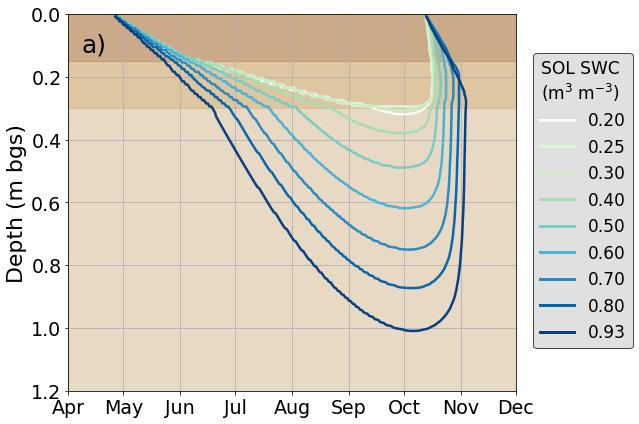

In [15]:

datasets = (T_dfse['df_20'],T_dfse['df_25'],T_dfse['df_30'],T_dfse['df_40'],T_dfse['df_50'],T_dfse['df_60'],
           T_dfse['df_70'],T_dfse['df_80'],T_dfse['df_93'])
labels = ('0.20','0.25','0.30','0.40','0.50','0.60','0.70','0.80', '0.93')


# --- Generate progressively darker blue colors (light to dark) ---
blues = plt.cm.PuBu(np.linspace(0.1, 1.0, len(datasets)))  # 0.3 = light, 1.0 = dark

# --- Plot ---`
fig, ax = plt.subplots(figsize=(9, 6))

ax.axhspan(0.0, 0.15, color='saddlebrown', alpha=0.5)
ax.axhspan(0.15, 0.30, color='darkgoldenrod', alpha=0.3)
ax.axhspan(0.0, 5, color='tan', alpha=0.5)

    
# --- Generate progressively darker blue colors (light to dark) ---
blues = plt.cm.GnBu(np.linspace(0, 1, len(datasets)))  # 0.3 = light, 1.0 = dark
for data, color in zip(datasets, blues):
    Time, Depth = np.meshgrid(data.index, data.columns, indexing='ij')
    ax.contour(Time, Depth, data.values, levels=[0], colors=[color], linewidths=2.5)
# --- Make custom legend lines (so colors show up) ---
legend_lines = [
    mlines.Line2D([], [], color=color, lw=3, label=label)
    for color, label in zip(blues, labels)
]
ax.invert_yaxis()
ax.set_ylabel("Depth (m bgs)", fontsize = 22)
#ax.set_xlim(3450, 3750)
ax.set_ylim(1.2, 0)
ax.tick_params(axis='both', labelsize=19) 
ax.grid()

# --- Add legend ---
leg = ax.legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.09),
    fontsize=17,
    title='SOL SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 17}
)
leg.get_frame().set_facecolor('lightgrey')
leg.get_frame().set_alpha(0.7) 
leg.get_frame().set_edgecolor('black')

start_date = pd.to_datetime('2000-04-01')
end_date = pd.to_datetime('2000-12')
ax.set_xlim(start_date, end_date)
ax.xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax.text(
    0.03, 0.95,
    "a)",
    transform=ax.transAxes,
    fontsize=25,
    va='top')

fig.tight_layout()
fig.subplots_adjust(hspace=0.1)

In [16]:
dfs = [T_dfs['df_20'],T_dfs['df_25'],T_dfs['df_30'],T_dfs['df_40'],T_dfs['df_50'], T_dfs['df_60'], T_dfs['df_70'],T_dfs['df_80'],T_dfs['df_90'],T_dfs['df_93']]

In [17]:
def surface_thaw_depth(row, depths):
    vals = row.values.astype(float)

    # If surface is frozen, no active-layer thaw
    if vals[0] < 0:
        return 0.0

    # Find first frozen point below the surface
    frozen = np.where(vals < 0)[0]

    if len(frozen) == 0:
        return depths[-1]

    i = frozen[0]

    # First point is frozen
    if i == 0:
        return 0.0

    # Linear interpolation to 0°C crossing
    T1, T2 = vals[i-1], vals[i]
    z1, z2 = depths[i-1], depths[i]

    z0 = z1 + (0 - T1) * (z2 - z1) / (T2 - T1)

    return z0

In [18]:
def equilibriated(df, start=900, end=1450, tol=0.01):

    depths = df.columns.astype(float).values
    L = end - start

    # ---- Last year ----
    sub1 = df.iloc[start:end]

    thaw1 = sub1.apply(
        lambda row: surface_thaw_depth(row, depths),
        axis=1
    )

    d1 = thaw1.max()

    # ---- Previous year ----
    sub2 = df.iloc[start-L:start]

    thaw2 = sub2.apply(
        lambda row: surface_thaw_depth(row, depths),
        axis=1
    )

    d2 = thaw2.max()

    # ---- Compare ----
    diff = abs(d1 - d2)

    if diff <= tol:
        print(
            f"Equilibrated: {d1:.3f} vs {d2:.3f} "
            f"(diff = {diff:.4f})"
        )
    else:
        print(
            f"Different: {d1:.3f} vs {d2:.3f} "
            f"(diff = {diff:.4f})"
        )

    return d1, d2

In [19]:
for df in dfs:
    equilibriated(df)

Equilibrated: 0.319 vs 0.319 (diff = 0.0007)
Equilibrated: 0.295 vs 0.295 (diff = 0.0004)
Equilibrated: 0.305 vs 0.306 (diff = 0.0011)
Equilibrated: 0.379 vs 0.379 (diff = 0.0006)
Equilibrated: 0.488 vs 0.489 (diff = 0.0006)
Equilibrated: 0.617 vs 0.618 (diff = 0.0011)
Equilibrated: 0.750 vs 0.750 (diff = 0.0009)
Equilibrated: 0.872 vs 0.873 (diff = 0.0008)
Equilibrated: 0.980 vs 0.981 (diff = 0.0009)
Equilibrated: 1.008 vs 1.009 (diff = 0.0010)


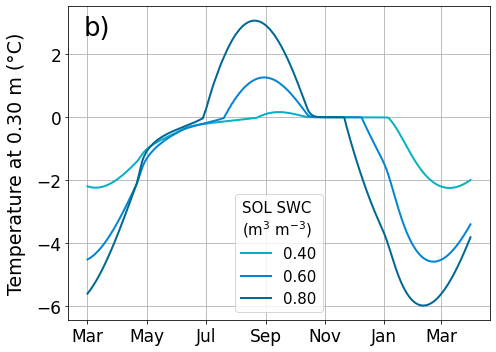

In [20]:

fig, ax = pl.subplots(figsize=(7, 5), sharex=True)

a = '2001-03'
b = '2002-03'

# ---------- TOP PANEL (unchanged) ----------
ax.plot(
    T_dfse['df_40'][0.305].loc[a:b],
    label='0.40',
    color='xkcd:turquoise blue',
    linewidth=2)

ax.plot(
    T_dfse['df_60'][0.305].loc[a:b],
    label='0.60',
    color='xkcd:cerulean',
    linewidth=2)

ax.plot(
    T_dfse['df_80'][0.305].loc[a:b],
    label='0.80',
    color='xkcd:peacock blue',
    linewidth=2)

ax.xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax.grid()

# ---------- LEGENDS & LABELS ----------
ax.legend(
    fontsize=15,
    loc='lower center',
    title='SOL SWC \n(m$^3$ m$^{-3}$)',
    title_fontsize=15)
ax.set_ylabel('Temperature at 0.30 m (°C)', fontsize=19, labelpad=10)
ax.tick_params(axis='both', labelsize=17)
fig.subplots_adjust(hspace=0.1)

# ---------- PANEL LABELS ----------
ax.text(
    0.1, 0.89, "b)",
    transform=ax.transAxes,
    fontsize=26,
    ha="right",
    va="bottom")


pl.tight_layout()


###### 

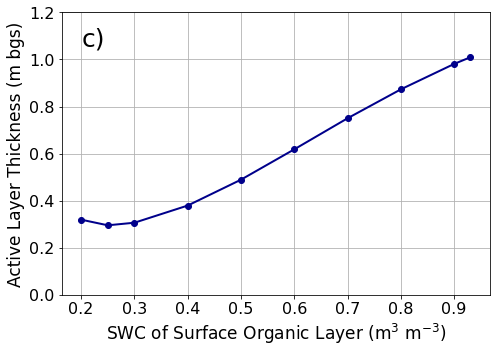

In [21]:

ALT = [0.319,0.295,0.306,0.379,0.489,0.618,0.750,0.873,0.981,1.009]

VWC = [0.20,0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.9, 0.93]
# Plot
plt.figure(figsize=(7,5))
plt.plot(VWC, ALT, marker='o', linewidth=2, color = 'darkblue')

plt.xlabel('SWC of Surface Organic Layer (m$^3$ m$^{-3}$)', fontsize=17)
plt.ylabel('Active Layer Thickness (m bgs)', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().invert_yaxis()
plt.grid(True)
plt.ylim(0,1.2)

# Upper left text
plt.text(
    0.20, 1.14  ,              # x, y in data coordinates
    'c)',
    fontsize=25,
    ha='left',
    va='top'
)
plt.tight_layout()
